In [1]:
#Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import ast 

#Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Filter jobs for Data analyst and US
# Drop na(blank) values in salary_year_avg column
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

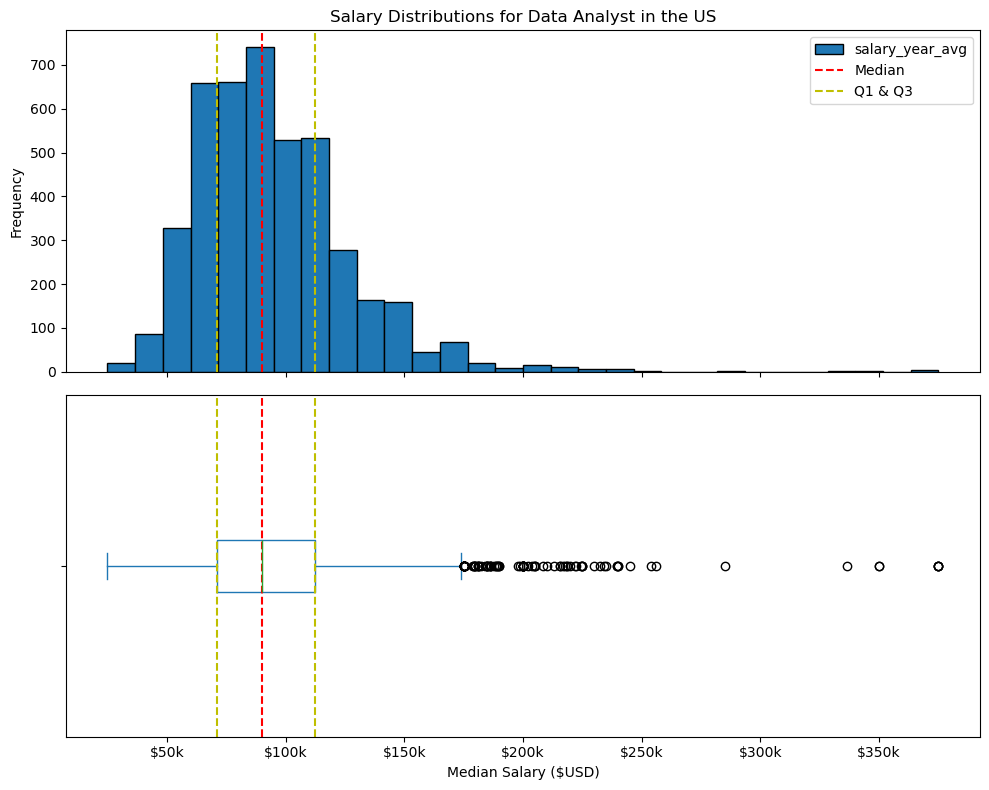

In [3]:
from matplotlib.ticker import FuncFormatter

# 1. Setup the figure with two subplots (Axes) stacked vertically
# sharex=True ensures both plots use the same horizontal scale
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# 2. Histogram (Top Plot - ax[0])
df_DA_US['salary_year_avg'].plot(kind='hist', bins=30, edgecolor='black', ax=ax[0], color='tab:blue')
ax[0].set_title('Salary Distributions for Data Analyst in the US')
ax[0].set_ylabel('Frequency')

# 3. Box Plot (Bottom Plot - ax[1])
df_DA_US['salary_year_avg'].plot(kind='box', vert=False, ax=ax[1], patch_artist=False)
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_yticklabels([]) # Hide the default boxplot y-label

# 4. Adding the Statistical Lines (Median and Quartiles)
median = df_DA_US['salary_year_avg'].median()
q1 = df_DA_US['salary_year_avg'].quantile(0.25)
q3 = df_DA_US['salary_year_avg'].quantile(0.75)

for a in ax:
    a.axvline(median, color='red', linestyle='--', label='Median')
    a.axvline(q1, color='y', linestyle='--', label='Q1 & Q3')
    a.axvline(q3, color='y', linestyle='--')

# 5. Formatting the X-axis to $K
def salary_formatter(x, pos):
    return f'${int(x/1000)}k'

ax[1].xaxis.set_major_formatter(plt.FuncFormatter(salary_formatter))

# 6. Final Polish
ax[0].legend(['salary_year_avg', 'Median', 'Q1 & Q3'], loc='upper right')
plt.tight_layout()
plt.show()